# Data Testing Zone
This is where we will be testing our data and making sure it is in the correct format for our project. We will be using the data provided by Kaggle, which contains the daily Spotify top 50 songs of 60 countries. We will be using this data to extract lyrics and other song information for our project.

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px # For the interactive geospatial/scatter plots

/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_combined_data(date):
    lyrics_df = pd.read_csv(f'../../data/spotify-global-50/lyrics/{date}_df_tracks_lyrics.csv', header=0)
    meta_df = pd.read_csv(f'../../data/spotify-global-50/metadata/{date}_df_playlist_tracks_metadata.csv')
    df = pd.merge(lyrics_df, meta_df, on='track.id') 
    unique_songs = df.drop_duplicates(subset=['track.id'])
    return unique_songs

In [3]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

songs = get_combined_data('022023')

# This will take a few minutes depending on your CPU/GPU
embeddings = model.encode(songs['lyrics'].tolist(), show_progress_bar=True)

Batches:   1%|▏         | 1/72 [00:04<05:42,  4.82s/it]


KeyboardInterrupt: 

## Prepare Embeddings

In [ ]:
import torch

dates = ['112022','122022','012023', '022023', '032023', '042023', '052023', '062023', '072023', '082023']

# Load and combine all lyrics data
song_dfs = [get_combined_data(date) for date in dates]

# Generate embeddings for all the songs
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f"Generating embeddings for {len(song_dfs)} total songs...")

# 1. Check for Apple Silicon GPU (MPS)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Combine all dataframes
all_songs_df = pd.concat(song_dfs, ignore_index=True)

print(f"Processing {len(all_songs_df)} songs on M4 GPU...")

# 4. Generate embeddings
# Note: show_progress_bar=True is helpful for long batches
embeddings = model.encode(
    all_songs_df['lyrics'].tolist(), 
    batch_size=64,  # Increased batch size to saturate the GPU
    show_progress_bar=True,
    convert_to_numpy=True
)

# 5. Store and Save
all_songs_df['embedding'] = list(embeddings)
all_songs_df.to_pickle('all_songs_embeddings.pkl')

print("Done! Data saved to all_songs_embeddings.pkl")

Generating embeddings for 10 total songs...
Using device: mps
Processing 23416 songs on M4 GPU...


Batches:  25%|██▍       | 91/366 [00:25<01:18,  3.51it/s]


KeyboardInterrupt: 

In [4]:
# Load Embeddings
all_songs_df = pd.read_pickle('all_songs_embeddings.pkl')
embeddings = all_songs_df['embedding'].tolist()
print(f"Loaded embeddings for {len(all_songs_df)} songs")

Loaded embeddings for 23416 songs


# 3D PCA Visualization of Song Embeddings

In [5]:
pca = PCA(n_components=3)
components = pca.fit_transform(embeddings)

# Add back to dataframe for plotting
all_songs_df['pca_1'] = components[:, 0]
all_songs_df['pca_2'] = components[:, 1]
all_songs_df['pca_3'] = components[:, 2]

# Check if your column is actually 'artist.name' or similar
# Based on your error, 'track.name' is definitely the correct one.
# Let's verify the column names first if this fails, 
# but this should fix the immediate ValueError:

fig = px.scatter_3d(
    all_songs_df, 
    x='pca_1', 
    y='pca_2', 
    z='pca_3',
    # We don't see 'country_code' in your error list, 
    # check if it is actually 'playlist.name' or another column for color
    color='playlist.name', 
    hover_data=['track.name'], # Removed 'artist_name' to be safe, add 'artist.name' if it exists
    title="Semantic Mapping of Global Diverse Voices"
)

fig.update_traces(marker=dict(size=3)) # Makes the dots readable in 3D
fig.show()



### What to Highlight in the 3D Map
- Dense, color-specific pockets show that playlists from the same market tend to share lyrical semantics even before clustering.
- Lighter scatter around the edges suggests cross-market hits; call these out when you hover so the audience can connect artists to locations.
- Mention the explained variance from PCA to frame this view as a faithful, but still lossy, projection of the full embedding space.

# Centroids

In [ ]:
# Calculate the mean PCA coordinates for each country
centroids = songs.groupby('playlist.name')[['pca_1', 'pca_2', 'pca_3']].mean().reset_index()

fig_centers = px.scatter_3d(centroids, x='pca_1', y='pca_2', z='pca_3',
                            text='playlist.name', title="Semantic Centers of Global Music")
fig_centers.show()

# K-means Clustering of Songs into Semantic Themes

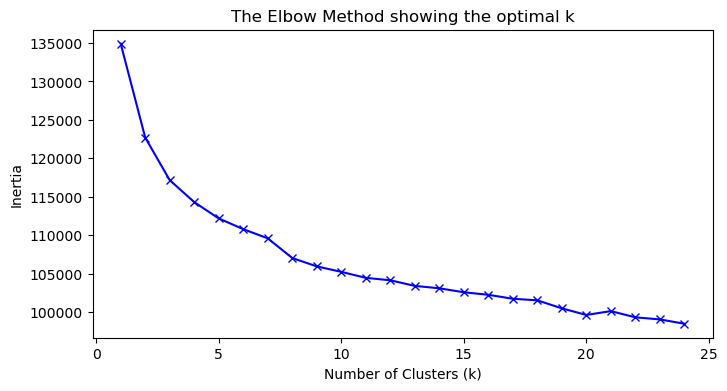

In [ ]:
# Inertial elbow method to find optimal clusters
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 25)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(embeddings)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [ ]:
from operator import index
import plotly.graph_objects as go

CLUSTERS = 7
kmeans = KMeans(n_clusters=CLUSTERS, init='k-means++', random_state=42)
all_songs_df['cluster'] = kmeans.fit_predict(embeddings)

fig_clusters = px.scatter_3d(all_songs_df, x='pca_1', y='pca_2', z='pca_3',
                             color='cluster', hover_data=['track.name', 'playlist.name'])
fig_clusters.show()

# Heat Map
ct = pd.crosstab(all_songs_df['playlist.name'], all_songs_df['cluster'], normalize='index')

# 2. Plot the Heatmap
fig_heatmap = px.imshow(
    ct, 
    labels=dict(x="Semantic Cluster", y="Country/Market", color="Proportion of Tracks"),
    x=[f"Cluster {i}" for i in range(ct.shape[1])],
    aspect="auto",
    title="Cultural Cluster Fingerprints (Normalized by Country)",
    color_continuous_scale='agsunset'
)

fig_heatmap.update_layout(height=800) # Makes it readable for many countries
fig_heatmap.show()
# ==== Frequency Analysis of Cluster Themes ====
# Function to get most frequent words in a cluster (Simple version)
from collections import Counter
import re

def get_cluster_keywords(df, cluster_id, top_n=10):
    # Combine all lyrics in the cluster
    text = " ".join(df[df['cluster'] == cluster_id]['lyrics'].astype(str)).lower()
    # Simple regex to find words (you might want to remove stopwords later)
    words = re.findall(r'\w+', text)

    for word in words:
        word = word.replace(u'\ufffd', '8')   # Replaces the ASCII '' symbol with '8'
        word = word.replace(',', '')          # Removes commas
        word = word.rstrip('\n')              # Removes line breaks
    # Filter for words longer than 3 letters to avoid 'the', 'and', etc.
    words = [w for w in words if len(w) > 3]
    return Counter(words).most_common(top_n)

def get_cluster_countries(df, cluster_id, top_n=5):
    countries = df[df['cluster'] == cluster_id]['playlist.name']
    return Counter(countries).most_common(top_n)

# Helper to format the list output for the table
def get_top_str(items):
    return ", ".join([str(x[0]) for x in items[:5]])

summary_data = []

for i in range(CLUSTERS): # Use your optimized K
    keywords = get_cluster_keywords(all_songs_df, i, top_n=8)
    countries = get_cluster_countries(all_songs_df, i, top_n=3)
    
    summary_data.append({
        "Cluster": f"Cluster {i}",
        "Top Keywords": get_top_str(keywords),
        "Primary Markets": get_top_str(countries),
        "Song Count": len(all_songs_df[all_songs_df['cluster'] == i])
    })

summary_df = pd.DataFrame(summary_data)

# Pretty Print with Color
summary_df.style.set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
    .background_gradient(subset=['Song Count'], cmap='viridis')




,Cluster,Top Keywords,Primary Markets,Song Count
0,Cluster 0,"yeah, baby, pero, como, parma","Top 50 - Chile, Top 50 - Finland, Top 50 - Italy",3277
1,Cluster 1,"love, your, that, baby, yeah","Top 50 - Indonesia, Top 50 - Turkey, Top 50 - Argentina",3585
2,Cluster 2,"that, yeah, your, know, just","Top 50 - Vietnam, Top 50 - Japan, Top 50 - Hong Kong",3250
3,Cluster 3,"bana, apana, bhee, tere, piya","Top 50 - India, Top 50 - Morocco, Top 50 - South Africa",1880
4,Cluster 4,"yeah, that, like, baby, know","Top 50 - Denmark, Top 50 - Brazil, Top 50 - Norway",3678
5,Cluster 5,"that, wanna, know, yeah, time","Top 50 - Thailand, Top 50 - Hong Kong, Top 50 - Taiwan",3838
6,Cluster 6,"yeah, that, like, money, dans","Top 50 - France, Top 50 - Greece, Top 50 - Slovakia",3908


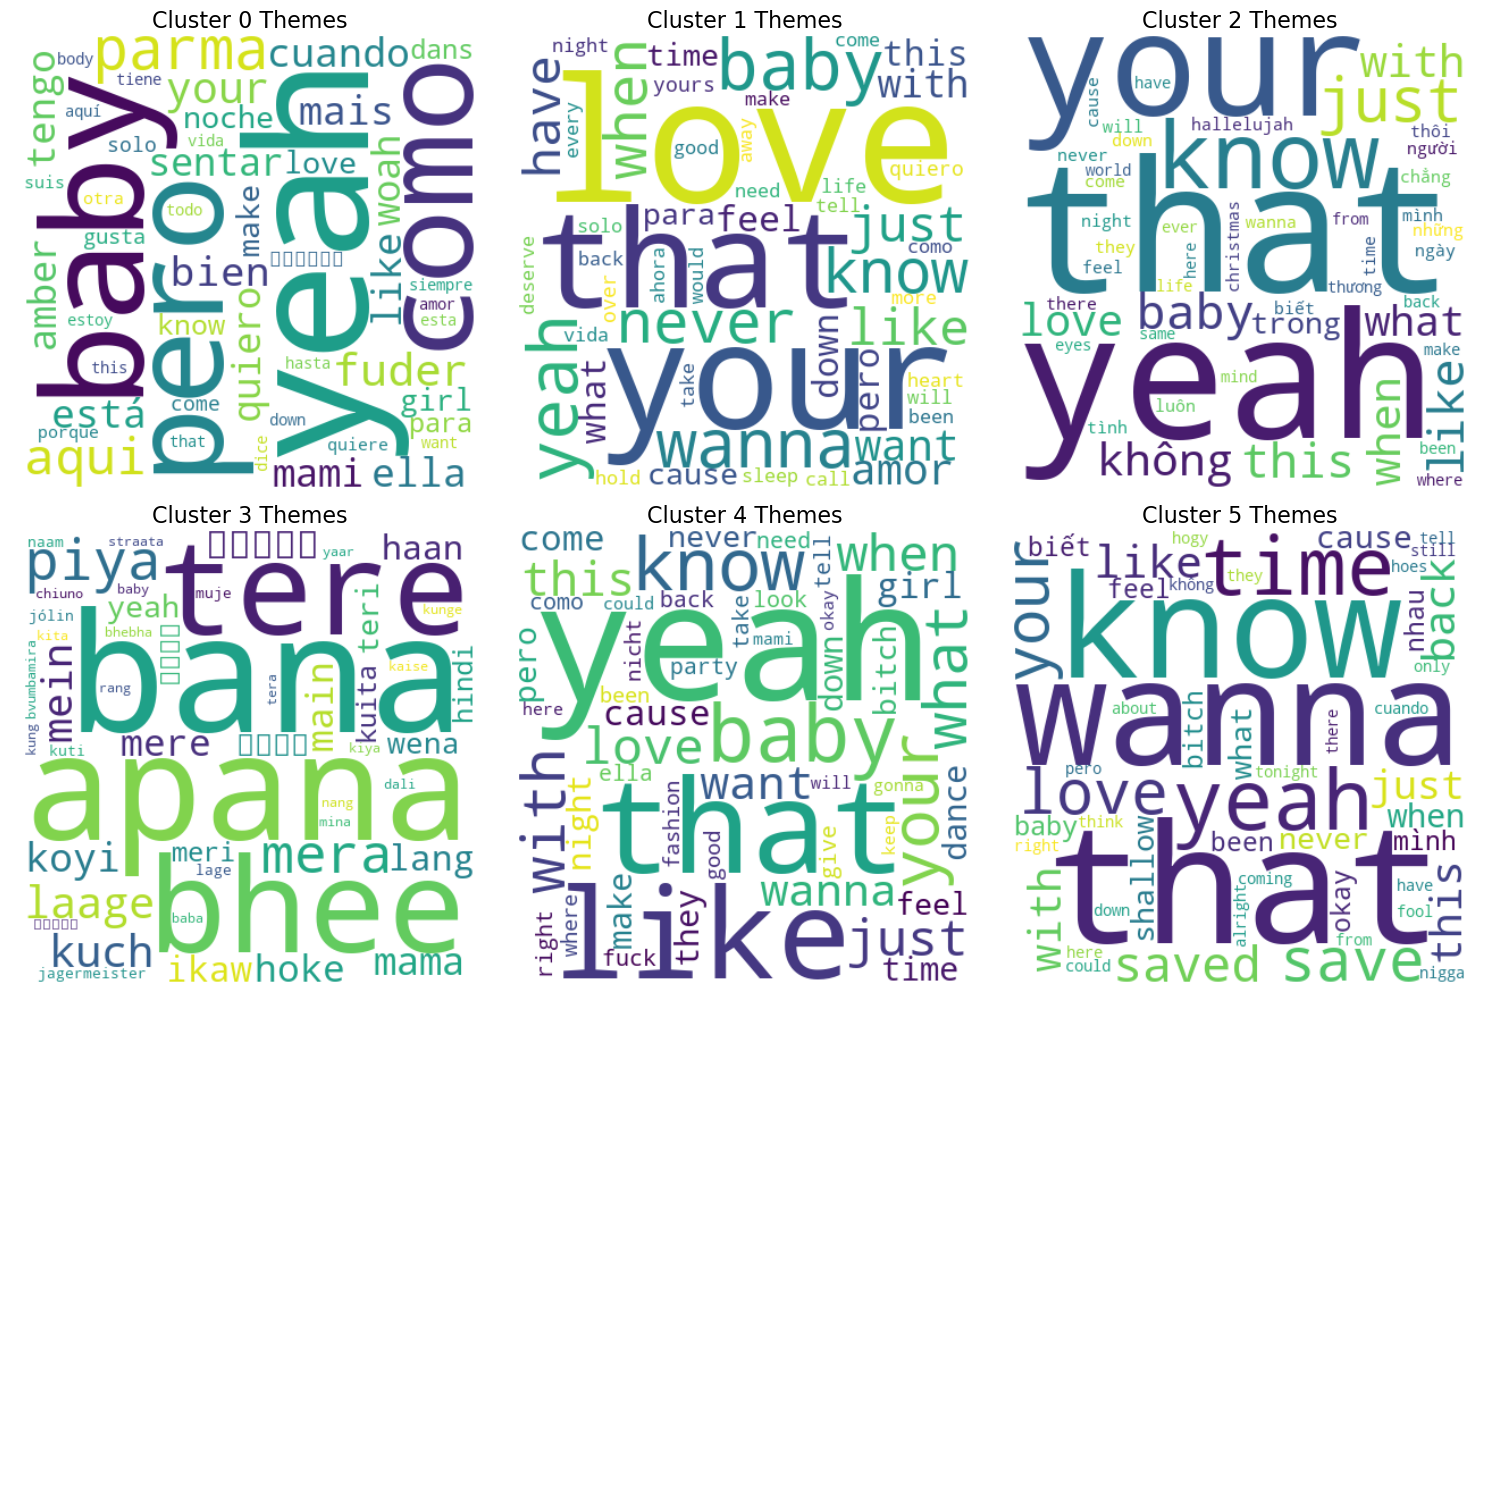

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_cluster_wordclouds(df, k):
    cols = 3
    rows = (k // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i in range(k):
        # Get keywords as a dictionary for the wordcloud
        words = dict(get_cluster_keywords(df, i, top_n=50))
        
        wc = WordCloud(background_color='white', width=400, height=400).generate_from_frequencies(words)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"Cluster {i} Themes", fontsize=16)
        axes[i].axis('off')

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_cluster_wordclouds(all_songs_df, 6)

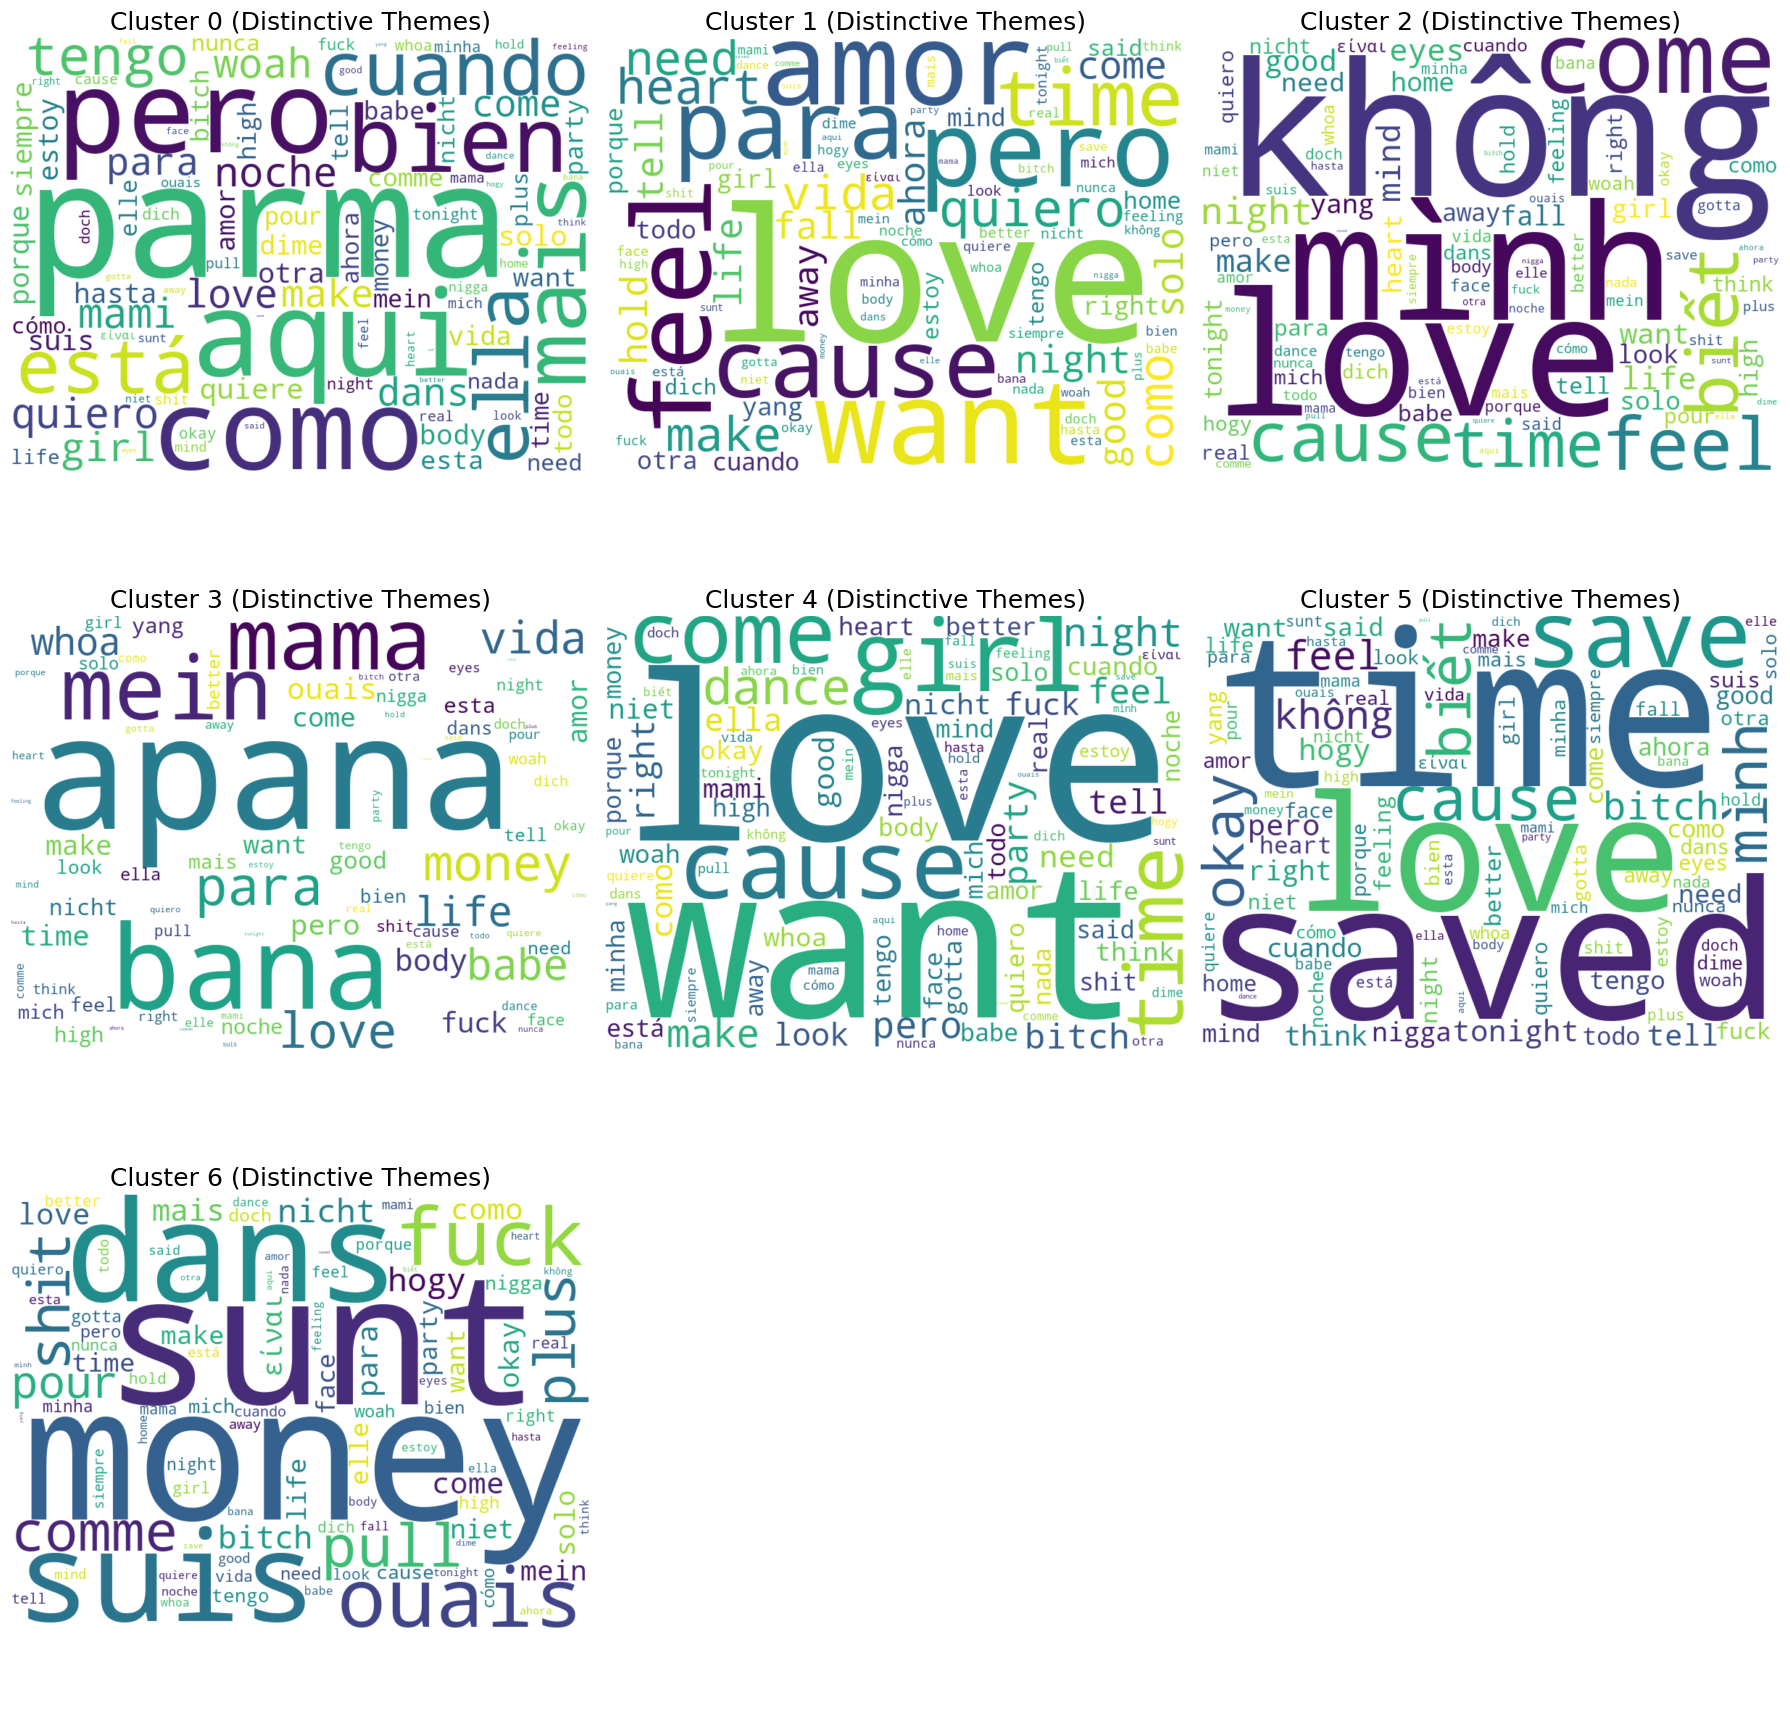

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction import text

def plot_tfidf_wordclouds(df, k_clusters):
    # 1. Prepare the "documents" (one per cluster)
    cluster_docs = []
    for i in range(k_clusters):
        cluster_text = " ".join(df[df['cluster'] == i]['lyrics'].astype(str))
        cluster_docs.append(cluster_text)

    # 2. Define custom stop words to filter out "yeah", "ooh", etc.
    custom_stop_words = ['yeah', 'wanna', 'gonna', 'baby', 'ooh', 'like', 'got', 'know', 'la', 'da', "just"]
    stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stop_words))
    
    # 3. Initialize TF-IDF Vectorizer
    # token_pattern=r"(?u)\b\w\w\w+\b" ensures words are at least 3 characters long
    tfidf = TfidfVectorizer(
        stop_words=stop_words, 
        max_features=100,
        token_pattern=r"(?u)\b\w\w\w\w+\b" 
    )

    # 4. Fit and transform
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()

    # 5. Plotting
    cols = 3
    rows = (k_clusters // cols) + (1 if k_clusters % cols != 0 else 0)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = axes.flatten()

    for i in range(k_clusters):
        scores = tfidf_matrix[i].toarray().flatten()
        word_scores = dict(zip(feature_names, scores))
        
        # Filter out zero scores
        word_scores = {w: s for w, s in word_scores.items() if s > 0}

        if word_scores:
            wc = WordCloud(
                background_color='white', 
                width=800, 
                height=600,
                colormap='viridis'
            ).generate_from_frequencies(word_scores)
            
            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].set_title(f"Cluster {i} (Distinctive Themes)", fontsize=18)
        
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Run the updated function
plot_tfidf_wordclouds(all_songs_df, CLUSTERS)

## Cluster Insight Add-ons
To keep your existing exploration intact while adding presentation-ready takeaways, the cells below layer on:
- quantitative profiles per cluster (popularity, lexical richness, geographic spread)
- TF-IDF driven distinctive vocab that filters out high-frequency filler words
- temporal trends that show when each lyrical mood peaks
- auto-generated talking points to drop directly into a deck
Run them after the clustering section so every helper can reuse the data already in memory.

In [ ]:
# Cluster-level descriptive statistics for storytelling
import numpy as np
import re

def compute_cluster_profiles(df, cluster_col='cluster'):
    if cluster_col not in df.columns:
        raise ValueError("Cluster labels not found. Run the KMeans cell first.")

    date_col = next((c for c in ['playlist.track.extracteddate', 'added_date'] if c in df.columns), None)
    records = []

    for cluster_id, cluster_df in df.groupby(cluster_col):
        lyrics = cluster_df['lyrics'].dropna().astype(str)
        avg_tokens = np.nan
        unique_share = np.nan

        if not lyrics.empty:
            token_series = lyrics.str.split().apply(len)
            avg_tokens = float(token_series.mean()) if not token_series.empty else np.nan
            token_stream = re.findall(r'\w+', " ".join(lyrics).lower())
            unique_share = len(set(token_stream)) / len(token_stream) if token_stream else np.nan

        snapshot_window = np.nan
        recent_share = np.nan
        if date_col:
            snapshot_series = pd.to_datetime(cluster_df[date_col], errors='coerce')
            if snapshot_series.notna().any():
                snapshot_window = (snapshot_series.max() - snapshot_series.min()).days
                cutoff = snapshot_series.max() - pd.Timedelta(days=30)
                recent_share = float((snapshot_series >= cutoff).mean() * 100)

        top_markets = ", ".join(cluster_df['playlist.name'].value_counts().head(3).index.tolist())
        top_keywords = ", ".join([kw for kw, _ in get_cluster_keywords(df, cluster_id, top_n=5)])

        records.append({
            'cluster': int(cluster_id),
            'song_count': int(cluster_df.shape[0]),
            'unique_markets': int(cluster_df['playlist.name'].nunique()),
            'top_markets': top_markets,
            'median_popularity': float(cluster_df['track.popularity'].median()) if 'track.popularity' in cluster_df.columns else np.nan,
            'lexical_avg_tokens': round(avg_tokens, 1) if not np.isnan(avg_tokens) else np.nan,
            'lexical_unique_share': round(unique_share, 3) if not np.isnan(unique_share) else np.nan,
            'recent_30d_share_pct': round(recent_share, 1) if not np.isnan(recent_share) else np.nan,
            'snapshot_window_days': snapshot_window,
            'top_keywords': top_keywords
        })

    profiles = pd.DataFrame(records).sort_values('cluster').reset_index(drop=True)
    return profiles

cluster_profiles = compute_cluster_profiles(all_songs_df)
cluster_profiles

,cluster,song_count,unique_markets,top_markets,median_popularity,lexical_avg_tokens,lexical_unique_share,recent_30d_share_pct,snapshot_window_days,top_keywords
0,0,3277,66,"Top 50 - Chile, Top 50 - Finland, Top 50 - Italy",65.0,375.2,0.042,8.7,303,"yeah, baby, pero, como, parma"
1,1,3585,67,"Top 50 - Indonesia, Top 50 - Turkey, Top 50 - ...",68.0,297.7,0.031,9.9,303,"love, your, that, baby, yeah"
2,2,3250,66,"Top 50 - Vietnam, Top 50 - Japan, Top 50 - Hon...",62.0,237.5,0.061,9.3,303,"that, yeah, your, know, just"
3,3,1880,59,"Top 50 - India, Top 50 - Morocco, Top 50 - Sou...",57.0,247.7,0.063,10.0,301,"bana, apana, bhee, tere, piya"
4,4,3678,67,"Top 50 - Denmark, Top 50 - Brazil, Top 50 - No...",66.0,365.7,0.037,9.9,303,"yeah, that, like, baby, know"
5,5,3838,67,"Top 50 - Thailand, Top 50 - Hong Kong, Top 50 ...",64.0,282.7,0.044,8.7,303,"that, wanna, know, yeah, time"
6,6,3908,67,"Top 50 - France, Top 50 - Greece, Top 50 - Slo...",57.0,386.1,0.054,8.0,303,"yeah, that, like, money, dans"


In [ ]:
# Reduce duplicate high-frequency words by surfacing distinctive TF-IDF terms per cluster
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text

def build_distinctive_keyword_table(df, cluster_col='cluster', top_n=6):
    if cluster_col not in df.columns:
        raise ValueError("Cluster labels missing from dataframe.")

    cluster_ids = sorted(df[cluster_col].unique())
    docs = [" ".join(df[df[cluster_col] == cid]['lyrics'].fillna('').astype(str)) for cid in cluster_ids]

    if not any(doc.strip() for doc in docs):
        return pd.DataFrame(columns=['cluster', 'distinctive_terms'])

    custom_stop = {'yeah', 'wanna', 'gonna', 'baby', 'ooh', 'like', 'got', 'know', 'la', 'da', 'just'}
    stop_words = sk_text.ENGLISH_STOP_WORDS.union(custom_stop)

    vectorizer = TfidfVectorizer(
        stop_words=list(stop_words),
        token_pattern=r"(?u)\b\w\w\w+\b",
        max_features=500
    )

    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_names = np.array(vectorizer.get_feature_names_out())

    cluster_term_scores = {}
    overlap_counts = Counter()

    for idx, cid in enumerate(cluster_ids):
        scores = tfidf_matrix[idx].toarray().ravel()
        order = scores.argsort()[::-1]
        terms = [(feature_names[i], scores[i]) for i in order if scores[i] > 0]
        cluster_term_scores[cid] = terms
        overlap_counts.update([term for term, _ in terms[:top_n]])

    rows = []
    for cid in cluster_ids:
        filtered_terms = [term for term, _ in cluster_term_scores[cid] if overlap_counts[term] == 1][:top_n]
        if len(filtered_terms) < top_n:
            for term, _ in cluster_term_scores[cid]:
                if term not in filtered_terms:
                    filtered_terms.append(term)
                if len(filtered_terms) == top_n:
                    break
        rows.append({'cluster': int(cid), 'distinctive_terms': ", ".join(filtered_terms)})

    return pd.DataFrame(rows)

cluster_distinctive_terms = build_distinctive_keyword_table(all_songs_df)
cluster_distinctive_terms

,cluster,distinctive_terms
0,0,"parma, اوه, fuder, dey, por, est"
1,1,"por, let, time, jeg, che, dey"
2,2,"không, che, jeg, time, let, est"
3,3,"apana, piya, naa, laage, bhee, اوه"
4,4,"jeg, let, time, por, che, dey"
5,5,"time, saved, let, por, jeg, không"
6,6,"زیم, est, pas, les, jeg, che"


In [ ]:
# Track how each lyrical theme grows or fades over time

def plot_cluster_trend(df, cluster_col='cluster'):
    date_col = next((c for c in ['playlist.track.extracteddate', 'added_date'] if c in df.columns), None)
    if date_col is None:
        raise ValueError("Need either 'playlist.track.extracteddate' or 'added_date' to build the trend chart.")

    dated = df.copy()
    dated['snapshot'] = pd.to_datetime(dated[date_col], errors='coerce')
    dated = dated.dropna(subset=['snapshot'])

    if dated.empty:
        print("No valid timestamps after parsing; skipping trend chart.")
        return pd.DataFrame()

    dated['snapshot_month'] = dated['snapshot'].dt.to_period('M').dt.to_timestamp()

    monthly = (
        dated.groupby(['snapshot_month', cluster_col])['track.id']
        .nunique()
        .reset_index(name='track_count')
    )

    monthly['share'] = monthly.groupby('snapshot_month')['track_count'].transform(lambda x: x / x.sum())

    fig = px.area(
        monthly.sort_values('snapshot_month'),
        x='snapshot_month',
        y='share',
        color=cluster_col,
        title='Share of Top 50 Tracks per Cluster Over Time',
        labels={'snapshot_month': 'Snapshot Month', 'share': 'Share of Chart', cluster_col: 'Cluster'},
        groupnorm=None
    )
    fig.update_layout(yaxis_tickformat='.0%', hovermode='x unified')
    fig.show()

    return monthly

cluster_trend = plot_cluster_trend(all_songs_df)
cluster_trend.head()

,snapshot_month,cluster,track_count,share
0,2022-11-01,0,221,0.101190
1,2022-11-01,1,365,0.167125
2,2022-11-01,2,361,0.165293
3,2022-11-01,3,203,0.092949
4,2022-11-01,4,219,0.100275


In [ ]:
# Generate lightly automated talking points for slide decks

def build_cluster_talking_points(profile_df, trend_df, distinctive_df, cluster_col='cluster'):
    insights = []

    if profile_df is not None and not profile_df.empty:
        global_cluster = profile_df.sort_values('unique_markets', ascending=False).iloc[0]
        insights.append(
            f"Cluster {int(global_cluster['cluster'])} travels the widest, touching {int(global_cluster['unique_markets'])}+ markets with a median popularity score of {global_cluster['median_popularity']:.0f}."
        )

        if profile_df['lexical_unique_share'].notna().any():
            verbose_cluster = profile_df.sort_values('lexical_unique_share', ascending=False).iloc[0]
            insights.append(
                f"Cluster {int(verbose_cluster['cluster'])} packs the densest storytelling (avg {verbose_cluster['lexical_avg_tokens']:.0f} tokens/song, {verbose_cluster['lexical_unique_share']*100:.1f}% unique words), great for describing lyrical complexity."
            )

        if profile_df['recent_30d_share_pct'].notna().any():
            fresh_cluster = profile_df.sort_values('recent_30d_share_pct', ascending=False).iloc[0]
            insights.append(
                f"Cluster {int(fresh_cluster['cluster'])} supplied {fresh_cluster['recent_30d_share_pct']:.0f}% of the newest additions in the last 30 days—use it when talking about emerging stories."
            )

    if trend_df is not None and isinstance(trend_df, pd.DataFrame) and not trend_df.empty:
        latest_month = trend_df['snapshot_month'].max()
        latest_slice = trend_df[trend_df['snapshot_month'] == latest_month]
        if not latest_slice.empty:
            hottest = latest_slice.sort_values('share', ascending=False).iloc[0]
            month_str = latest_month.strftime('%b %Y') if hasattr(latest_month, 'strftime') else str(latest_month)
            insights.append(
                f"In {month_str}, Cluster {int(hottest[cluster_col])} owned {hottest['share']:.0%} of the Top 50 slots, signalling which mood currently leads the charts."
            )

    if distinctive_df is not None and not distinctive_df.empty:
        sample_row = distinctive_df.sample(1, random_state=42).iloc[0]
        insights.append(
            f"Cluster {int(sample_row['cluster'])} reads as {sample_row['distinctive_terms']} — a clean phrase bank for titling the segment."
        )

    return insights

cluster_talking_points = build_cluster_talking_points(cluster_profiles, cluster_trend, cluster_distinctive_terms)
for insight in cluster_talking_points:
    print(f"- {insight}")

if not cluster_talking_points:
    print("Run the previous helper cells first to populate automated insights.")

- Cluster 1 travels the widest, touching 67+ markets with a median popularity score of 68.
- Cluster 3 packs the densest storytelling (avg 248 tokens/song, 6.3% unique words), great for describing lyrical complexity.
- Cluster 3 supplied 10% of the newest additions in the last 30 days—use it when talking about emerging stories.
- In Aug 2023, Cluster 4 owned 17% of the Top 50 slots, signalling which mood currently leads the charts.
- Cluster 0 reads as parma, اوه, fuder, dey, por, est — a clean phrase bank for titling the segment.


### How to Present the New Evidence
- Reference the `cluster_profiles` table when you need quick proof points (reach, lexical richness, recency) for each semantic theme.
- Use `cluster_distinctive_terms` to caption slides or word clouds without repeating filler words; each list is filtered to terms that only spike in that cluster.
- Drop the stacked area chart from `plot_cluster_trend` into your narrative to explain how moods cycle over time and which themes currently lead.
- Paste the auto-generated bullet list when you need a TL;DR talking slide—rerun after filtering by region or time window to refresh the story.

### Next Analytical Hooks
- Layer in artist- or label-level pivots to show who is driving each cluster.
- Blend external events (holidays, releases) with the monthly trend to explain sudden spikes.
- Swap in sentiment or emotion lexicons to turn the distinctive vocabulary into plain-language theme names.

In [ ]:
Counter() 